In [1]:
import sys
from pathlib import Path

# Notebook nằm trong /Jupyter
ROOT = Path.cwd().parent               # project root: DL-DuDoan33MonAnVietNam
print("ROOT =", ROOT)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


ROOT = /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam


In [2]:
import torch
from model.mtl_efficientnet_b0 import mtl_efficientnet_b0_model

def _extract_state_and_classes(raw):
    names = None
    if isinstance(raw, dict):
        # lấy danh sách nhãn nếu có
        for k in ("class_names", "classes", "labels"):
            if k in raw and isinstance(raw[k], (list, tuple)):
                names = list(raw[k])
                break
        # lấy state_dict
        for k in ("state_dict", "model_state", "model_state_dict", "model"):
            if k in raw and isinstance(raw[k], dict):
                return raw[k], names
        return raw, names
    return raw, None

def _strip_prefix(k: str, pref: str) -> str:
    return k[len(pref):] if k.startswith(pref) else k

def _map_keys(sd: dict, how: str) -> dict:
    if how == "identity":
        return {k: v for k, v in sd.items()}
    if how == "strip_module":
        return {_strip_prefix(k, "module."): v for k, v in sd.items()}
    if how == "strip_1tok":
        return {(k.split(".", 1)[1] if "." in k else k): v for k, v in sd.items()}
    if how == "strip_2tok":
        return {(".".join(k.split(".")[2:]) if k.count(".") >= 2 else k): v for k, v in sd.items()}
    if how == "features_to_backbone":
        out = {}
        for k, v in sd.items():
            if k.startswith(("features.", "classifier.")):
                out["backbone." + k] = v
            else:
                out[k] = v
        return out
    return sd

def smart_load_weights(model, ckpt_path: Path, device: torch.device):
    raw = torch.load(ckpt_path, map_location=device)
    sd_raw, names = _extract_state_and_classes(raw)
    base = _map_keys(sd_raw, "strip_module")

    msd = set(model.state_dict().keys())
    best_hit = -1
    best_sd = None
    for how in ["identity", "features_to_backbone", "strip_1tok", "strip_2tok"]:
        cand = _map_keys(base, how)
        hit = len(msd.intersection(cand.keys()))
        if hit > best_hit:
            best_hit = hit
            best_sd = cand

    missing, unexpected = model.load_state_dict(best_sd, strict=False)
    hit = 100.0 * (len(msd) - len(missing)) / max(1, len(msd))
    print(f"Loaded weights: hit={hit:.1f}% · missing={len(missing)} · unexpected={len(unexpected)}")
    return names, missing, unexpected


In [3]:
from pathlib import Path

runs_dir = ROOT / "Jupyter" / "runs"
print("runs_dir:", runs_dir)

ckpt_list = sorted(
    runs_dir.glob("mtl_efficientnet_b0_01/checkpoints/*best*.pt")
)

print("Found checkpoints:")
for p in ckpt_list:
    print(" -", p)

if not ckpt_list:
    raise FileNotFoundError("Không tìm thấy checkpoint '*best*.pt' trong 'Jupyter/runs/mtl_efficientnet_b0_01/checkpoints'")

CKPT_PATH = ckpt_list[-1]  # lấy file cuối (thường mới nhất)
print("Using checkpoint:", CKPT_PATH)


runs_dir: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs
Found checkpoints:
 - /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_01/checkpoints/mtl_effcientnet_b0_best.pt
Using checkpoint: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/mtl_efficientnet_b0_01/checkpoints/mtl_effcientnet_b0_best.pt


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 1) build tạm model 33 lớp để đọc class_names từ checkpoint (nếu có)
tmp_model = mtl_efficientnet_b0_model(num_classes=33).to(device)
names_from_ckpt, *_ = smart_load_weights(tmp_model, CKPT_PATH, device)

if names_from_ckpt:
    CLASSES = names_from_ckpt
    print("Loaded class names from ckpt:", len(CLASSES))
else:
    # fallback danh sách 33 món cứng như app.py
    CLASSES = [
        "Bánh beo","Bánh bot loc","Bánh can","Bánh canh","Bánh chung","Bánh cuon","Bánh duc",
        "Bánh gio","Bánh khot","Bánh mi","Bánh pia","Bánh tet","Bánh trang nuong","Bánh xeo",
        "Bun bo Hue","Bun dau mam tom","Bun mam","Bun rieu","Bun thit nuong","Ca kho to","Canh chua",
        "Cao lau","Chao long","Com tam","Goi cuon","Hu tieu","Mi quang","Nem chua","Pho","Xoi xeo",
        "banh_da_lon","banh_tieu","banh_trung_thu",
    ]
    print("⚠️ Không thấy class_names trong ckpt, dùng list cứng 33 món.")

print("Số lớp:", len(CLASSES))

# 2) build model thật đúng num_classes
classifier = mtl_efficientnet_b0_model(num_classes=len(CLASSES)).to(device)
smart_load_weights(classifier, CKPT_PATH, device)
classifier.eval()

print("✅ EfficientNet đã sẵn sàng để infer.")


Device: cuda
Loaded weights: hit=100.0% · missing=0 · unexpected=0
Loaded class names from ckpt: 33
Số lớp: 33
Loaded weights: hit=100.0% · missing=0 · unexpected=0
✅ EfficientNet đã sẵn sàng để infer.


In [5]:
from PIL import Image
from torchvision import transforms
import torch.nn.functional as F
import numpy as np

IMG_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

@torch.inference_mode()
def predict_image(img: Image.Image, topk: int = 3):
    x = tfm(img).unsqueeze(0).to(device).to(memory_format=torch.channels_last)
    with torch.amp.autocast(device_type='cuda' if device.type=='cuda' else 'cpu'):
        logits = classifier(x)
        probs  = F.softmax(logits, dim=1)[0]
    conf, idx = torch.topk(probs, k=topk)
    conf = conf.cpu().numpy()
    idx  = idx.cpu().numpy()
    return [(CLASSES[i], float(c)) for i, c in zip(idx, conf)]


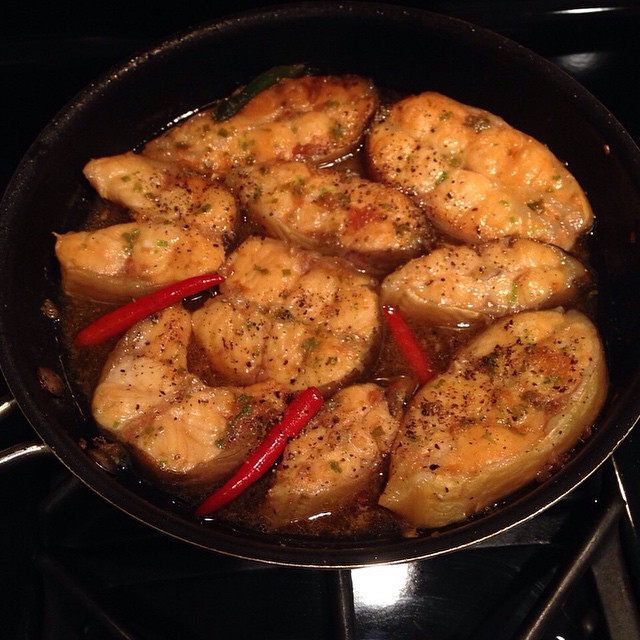

Ca kho to            : 100.00%
Banh xeo             :  0.00%
Bun bo Hue           :  0.00%


In [6]:
TEST_IMG = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images/Test/Ca kho to/103.jpg")  # đổi path cho đúng
TEST_IMG = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images/Test/Ca kho to/103.jpg")  # đổi path cho đúng
TEST_IMG = Path("/media/mtl/DATA 6TB/AI DATASET/vietnamese-foods/Images/Test/Ca kho to/103.jpg")  # đổi path cho đúng



img = Image.open(TEST_IMG).convert("RGB")
display(img)

results = predict_image(img, topk=3)
for name, prob in results:
    print(f"{name:20s} : {prob*100:5.2f}%")


In [7]:
# Nếu chưa có thì chạy 1 lần:
# !pip install -U ultralytics

from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw


WARNING ⚠️ Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at '/home/mtl/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
# Chọn file YOLO weights

YOLO_WEIGHTS = ROOT / "Jupyter/yolov8n.pt"   # ⚠️ sửa lại nếu cậu có model fine-tune riêng

print("YOLO weights:", YOLO_WEIGHTS)
if not YOLO_WEIGHTS.is_file():
    raise FileNotFoundError(f"Không thấy file YOLO: {YOLO_WEIGHTS}")

# Load YOLO
yolo_model = YOLO(str(YOLO_WEIGHTS))
yolo_model.to(device.type)  # dùng cùng GPU / CPU với EfficientNet

print("✅ YOLO model đã load trên", device)


YOLO weights: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/yolov8n.pt
✅ YOLO model đã load trên cuda


In [9]:
def detect_foods_yolo(pil_img: Image.Image,
                      conf_thres: float = 0.3,
                      iou_thres: float = 0.5):
    """
    Chạy YOLO trên 1 ảnh PIL, trả về:
      - boxes:  [N, 4]  (x1, y1, x2, y2)
      - scores: [N]     độ tin cậy YOLO
      - cls_ids:[N]     id class của YOLO (nếu có label)
    """
    # YOLO nhận numpy hoặc path đều được
    img_np = np.array(pil_img)

    results = yolo_model.predict(
        source=img_np,
        conf=conf_thres,
        iou=iou_thres,
        verbose=False
    )

    r = results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return np.zeros((0, 4), dtype=int), np.array([]), np.array([])

    boxes = r.boxes.xyxy.cpu().numpy().astype(int)   # (N, 4)
    scores = r.boxes.conf.cpu().numpy()             # (N,)
    cls_ids = r.boxes.cls.cpu().numpy().astype(int) # (N,)

    print(f"Phát hiện {len(boxes)} vùng món ăn (YOLO).")
    return boxes, scores, cls_ids


In [10]:
@torch.inference_mode()
def classify_yolo_regions(pil_img: Image.Image,
                          det_conf: float = 0.4,
                          det_iou: float = 0.5,
                          cls_thres: float = 0.5,
                          enlarge: float = 0.10):
    """
    - det_conf, det_iou: ngưỡng YOLO
    - cls_thres: ngưỡng tin cậy EfficientNet, dưới ngưỡng => UNKNOWN
    - enlarge: mở rộng bbox theo tỉ lệ (10% = 0.1)
    """
    w, h = pil_img.size

    boxes, det_scores, det_cls_ids = detect_foods_yolo(
        pil_img, conf_thres=det_conf, iou_thres=det_iou
    )

    if len(boxes) == 0:
        print("❗ YOLO không phát hiện vùng nào.")
        return [], pil_img

    draw_img = pil_img.copy()
    draw = ImageDraw.Draw(draw_img)

    results = []

    for i, (box, det_p) in enumerate(zip(boxes, det_scores)):
        x1, y1, x2, y2 = box

        # Mở rộng bbox 1 chút
        dx = int((x2 - x1) * enlarge)
        dy = int((y2 - y1) * enlarge)
        nx1 = max(0, x1 - dx)
        ny1 = max(0, y1 - dy)
        nx2 = min(w, x2 + dx)
        ny2 = min(h, y2 + dy)

        patch = pil_img.crop((nx1, ny1, nx2, ny2))

        # EfficientNet top-1
        cls_results = predict_image(patch, topk=1)
        top_name, top_prob = cls_results[0]

        if top_prob < cls_thres:
            label = f"UNKNOWN ({top_prob*100:.1f}%)"
            food_name = "UNKNOWN"
        else:
            label = f"{top_name} ({top_prob*100:.1f}%)"
            food_name = top_name

        # Vẽ khung
        draw.rectangle((nx1, ny1, nx2, ny2), outline="red", width=3)

        # Vị trí text
        text_x, text_y = nx1 + 4, ny1 + 4
        draw.text((text_x, text_y), label, fill="yellow")

        results.append({
            "box": (nx1, ny1, nx2, ny2),
            "yolo_score": float(det_p),
            "food_name": food_name,
            "cls_prob": float(top_prob),
        })

    print("Kết quả:")
    for i, r in enumerate(results, 1):
        print(f"[{i}] {r['food_name']:20s}  | cls={r['cls_prob']:.3f} | yolo={r['yolo_score']:.3f}")

    return results, draw_img


Ảnh size: (1920, 1280)
Phát hiện 12 vùng món ăn (YOLO).
Kết quả:
[1] Bun dau mam tom       | cls=0.865 | yolo=0.892
[2] banh_da_lon           | cls=0.940 | yolo=0.807
[3] UNKNOWN               | cls=0.609 | yolo=0.746
[4] Banh duc              | cls=0.999 | yolo=0.737
[5] UNKNOWN               | cls=0.664 | yolo=0.712
[6] Banh duc              | cls=0.747 | yolo=0.645
[7] UNKNOWN               | cls=0.533 | yolo=0.644
[8] Canh chua             | cls=1.000 | yolo=0.617
[9] UNKNOWN               | cls=0.674 | yolo=0.514
[10] Bun thit nuong        | cls=0.995 | yolo=0.510
[11] Goi cuon              | cls=1.000 | yolo=0.500
[12] Bun thit nuong        | cls=0.988 | yolo=0.464


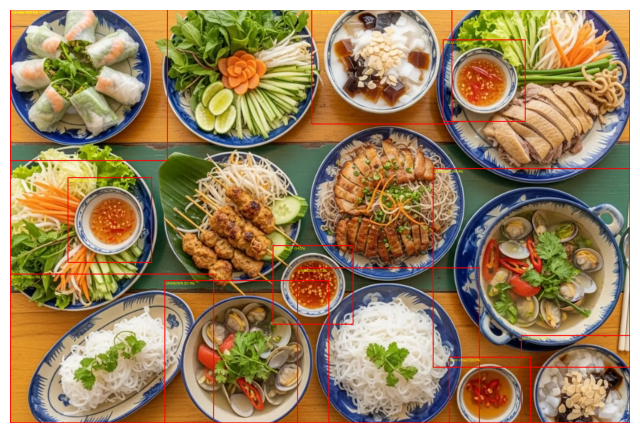

In [11]:
# Đổi path ảnh cho đúng máy cậu
TEST_IMG_PATH = Path("/home/mtl/Downloads/9_a59070c3d5.webp")

img = Image.open(TEST_IMG_PATH).convert("RGB")
print("Ảnh size:", img.size)

results, vis_img = classify_yolo_regions(
    img,
    det_conf=0.4,   # ngưỡng YOLO
    det_iou=0.5,
    cls_thres=0.7,  # ngưỡng tin cậy EfficientNet
    enlarge=0.12
)

plt.figure(figsize=(8, 8))
plt.imshow(vis_img)
plt.axis("off")
plt.show()


In [12]:
# ============================================================
# 📌 Cell: Tải & Load YOLOv8s-seg (Instance Segmentation)
# ============================================================

from ultralytics import YOLO
from pathlib import Path
import torch

# Đặt path lưu model seg trong project
YOLO_SEG_PATH = Path("yolov8s-seg.pt")

print("🔍 Kiểm tra YOLOv8s-seg:", YOLO_SEG_PATH.absolute())

# Nếu chưa có file -> tự download từ Ultralytics
if not YOLO_SEG_PATH.exists():
    print("⬇️  Chưa có file yolov8s-seg.pt → đang tải về...")
    import urllib.request

    url = "https://github.com/ultralytics/assets/releases/download/v8.0.0/yolov8s-seg.pt"
    urllib.request.urlretrieve(url, YOLO_SEG_PATH)
    print("✅ Tải hoàn tất:", YOLO_SEG_PATH)
else:
    print("✅ Đã có sẵn:", YOLO_SEG_PATH)

# Load model YOLO segmentation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
yolo_seg = YOLO(str(YOLO_SEG_PATH))
yolo_seg.to(device)

print(f"🚀 YOLOv8s-seg loaded on {device}")


🔍 Kiểm tra YOLOv8s-seg: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/yolov8s-seg.pt
✅ Đã có sẵn: yolov8s-seg.pt
🚀 YOLOv8s-seg loaded on cuda


In [13]:
from ultralytics import YOLO
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# Đường dẫn model seg (sửa lại cho đúng)
YOLO_SEG_WEIGHTS = ROOT / "Jupyter/yolov8s-seg.pt"

print("YOLO seg weights:", YOLO_SEG_WEIGHTS)
if not YOLO_SEG_WEIGHTS.is_file():
    raise FileNotFoundError(YOLO_SEG_WEIGHTS)

yolo_seg = YOLO(str(YOLO_SEG_WEIGHTS))
yolo_seg.to(device.type)

print("✅ YOLOv8-seg loaded on", device)


YOLO seg weights: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/yolov8s-seg.pt
✅ YOLOv8-seg loaded on cuda


In [14]:
def detect_foods_yolo(pil_img: Image.Image,
                      conf_thres: float = 0.3,
                      iou_thres: float = 0.5):
    """
    Chạy YOLO trên 1 ảnh PIL, trả về:
      - boxes:  [N, 4]  (x1, y1, x2, y2)
      - scores: [N]     độ tin cậy YOLO
      - cls_ids:[N]     id class của YOLO (nếu có label)
    """
    # YOLO nhận numpy hoặc path đều được
    img_np = np.array(pil_img)

    results = yolo_model.predict(
        source=img_np,
        conf=conf_thres,
        iou=iou_thres,
        verbose=False
    )

    r = results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return np.zeros((0, 4), dtype=int), np.array([]), np.array([])

    boxes = r.boxes.xyxy.cpu().numpy().astype(int)   # (N, 4)
    scores = r.boxes.conf.cpu().numpy()             # (N,)
    cls_ids = r.boxes.cls.cpu().numpy().astype(int) # (N,)

    print(f"Phát hiện {len(boxes)} vùng món ăn (YOLO).")
    return boxes, scores, cls_ids


In [15]:
@torch.inference_mode()
def classify_yolo_regions(pil_img: Image.Image,
                          det_conf: float = 0.4,
                          det_iou: float = 0.5,
                          cls_thres: float = 0.5,
                          enlarge: float = 0.10):
    """
    - det_conf, det_iou: ngưỡng YOLO
    - cls_thres: ngưỡng tin cậy EfficientNet, dưới ngưỡng => UNKNOWN
    - enlarge: mở rộng bbox theo tỉ lệ (10% = 0.1)
    """
    w, h = pil_img.size

    boxes, det_scores, det_cls_ids = detect_foods_yolo(
        pil_img, conf_thres=det_conf, iou_thres=det_iou
    )

    if len(boxes) == 0:
        print("❗ YOLO không phát hiện vùng nào.")
        return [], pil_img

    draw_img = pil_img.copy()
    draw = ImageDraw.Draw(draw_img)

    results = []

    for i, (box, det_p) in enumerate(zip(boxes, det_scores)):
        x1, y1, x2, y2 = box

        # Mở rộng bbox 1 chút
        dx = int((x2 - x1) * enlarge)
        dy = int((y2 - y1) * enlarge)
        nx1 = max(0, x1 - dx)
        ny1 = max(0, y1 - dy)
        nx2 = min(w, x2 + dx)
        ny2 = min(h, y2 + dy)

        patch = pil_img.crop((nx1, ny1, nx2, ny2))

        # EfficientNet top-1
        cls_results = predict_image(patch, topk=1)
        top_name, top_prob = cls_results[0]

        if top_prob < cls_thres:
            label = f"UNKNOWN ({top_prob*100:.1f}%)"
            food_name = "UNKNOWN"
        else:
            label = f"{top_name} ({top_prob*100:.1f}%)"
            food_name = top_name

        # Vẽ khung
        draw.rectangle((nx1, ny1, nx2, ny2), outline="red", width=3)

        # Vị trí text
        text_x, text_y = nx1 + 4, ny1 + 4
        draw.text((text_x, text_y), label, fill="yellow")

        results.append({
            "box": (nx1, ny1, nx2, ny2),
            "yolo_score": float(det_p),
            "food_name": food_name,
            "cls_prob": float(top_prob),
        })

    print("Kết quả:")
    for i, r in enumerate(results, 1):
        print(f"[{i}] {r['food_name']:20s}  | cls={r['cls_prob']:.3f} | yolo={r['yolo_score']:.3f}")

    return results, draw_img


Ảnh size: (1920, 1280)
Phát hiện 2 vùng món ăn (YOLO).
Kết quả:
[1] Bun dau mam tom       | cls=0.865 | yolo=0.892
[2] banh_da_lon           | cls=0.940 | yolo=0.807


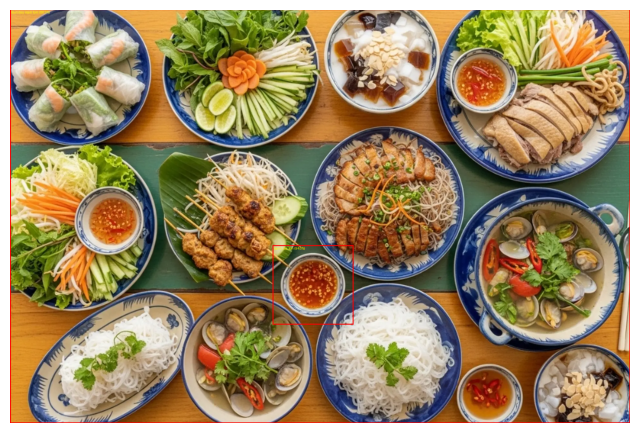

✅ Đã lưu ảnh kết quả tại: /home/mtl/Downloads/yolo_outputs/9_a59070c3d5 (1)_detected.jpg


In [22]:
# Đổi path ảnh cho đúng máy cậu

TEST_IMG_PATH = Path("/home/mtl/Downloads/9_a59070c3d5 (1).webp")

img = Image.open(TEST_IMG_PATH).convert("RGB")
print("Ảnh size:", img.size)

results, vis_img = classify_yolo_regions(
    img,
    det_conf=0.8,   # ngưỡng YOLO
    det_iou=0.5,
    cls_thres=0.8,  # ngưỡng tin cậy EfficientNet
    enlarge=0.12
)

plt.figure(figsize=(8, 8))
plt.imshow(vis_img)
plt.axis("off")
plt.show()

# ===== Lưu ảnh kết quả xuống ổ đĩa =====
from pathlib import Path

SAVE_DIR = Path("/home/mtl/Downloads/yolo_outputs")  # thư mục muốn lưu
SAVE_DIR.mkdir(parents=True, exist_ok=True)

out_path = SAVE_DIR / f"{TEST_IMG_PATH.stem}_detected.jpg"

# Nếu vis_img là PIL.Image (đúng với code mình viết trước đó)
vis_img.save(out_path, quality=95)

print("✅ Đã lưu ảnh kết quả tại:", out_path)


In [17]:
# Cell 1: Cài & import thư viện

%pip install -q ultralytics==8.3.0

from ultralytics import YOLO
from pathlib import Path
import os
import torch

print("✅ PyTorch:", torch.__version__)
print("✅ CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


Note: you may need to restart the kernel to use updated packages.
✅ PyTorch: 2.9.1+cu128
✅ CUDA available: True
GPU: Quadro RTX 5000


In [18]:
# Cell 2: Khai báo path & tạo file cấu hình dataset (YOLO seg)

DATA_ROOT = Path("/media/mtl/DATA 6TB/AI DATASET/vnfoods_seg")  # chỉnh lại đúng thư mục của cậu
IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"

train_images = IMAGES_DIR / "train"
val_images   = IMAGES_DIR / "val"
train_labels = LABELS_DIR / "train"
val_labels   = LABELS_DIR / "val"

print("📁 Train images :", train_images)
print("📁 Val images   :", val_images)
print("📁 Train labels :", train_labels)
print("📁 Val labels   :", val_labels)

for p in [train_images, val_images, train_labels, val_labels]:
    if not p.exists():
        print("⚠️ Thiếu thư mục:", p)


📁 Train images : /media/mtl/DATA 6TB/AI DATASET/vnfoods_seg/images/train
📁 Val images   : /media/mtl/DATA 6TB/AI DATASET/vnfoods_seg/images/val
📁 Train labels : /media/mtl/DATA 6TB/AI DATASET/vnfoods_seg/labels/train
📁 Val labels   : /media/mtl/DATA 6TB/AI DATASET/vnfoods_seg/labels/val
⚠️ Thiếu thư mục: /media/mtl/DATA 6TB/AI DATASET/vnfoods_seg/images/train
⚠️ Thiếu thư mục: /media/mtl/DATA 6TB/AI DATASET/vnfoods_seg/images/val
⚠️ Thiếu thư mục: /media/mtl/DATA 6TB/AI DATASET/vnfoods_seg/labels/train
⚠️ Thiếu thư mục: /media/mtl/DATA 6TB/AI DATASET/vnfoods_seg/labels/val
